Dataset:
    Food  Travel  Shopping  Bills  Others  Total
0   202     181       437    430     145   1395
1   448     138       152    436     162   1336
2   370     109       316    342     111   1248
3   206      63       287    370     101   1027
4   171     291       479    228      61   1230

Mean: 469.46
Sum: 140838
Shape: (50, 6)

Sample Data:
     Food  Travel  Shopping  Bills  Others  Total
13   199     237       571    265      51   1323
39   463     277       497    336     139   1712
30   444     103       602    584     188   1921
45   234     255       674    371      88   1622
17   249     224       692    333     178   1676
48   266     239       195    573     178   1451
26   413     183       234    547      73   1450
25   260      51       127    327      87    852
32   158     240       673    482     146   1699
19   357     255       518    227     175   1532
12   472     160       228    483     162   1505
4    171     291       479    228      61   1230


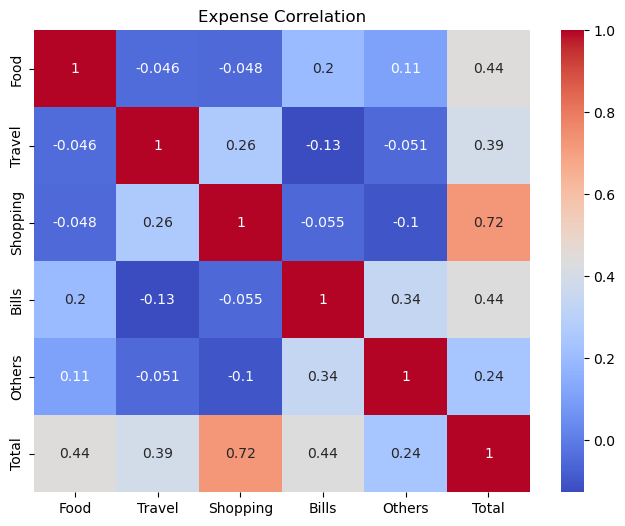


Z-score: -15.17
Fail to Reject Null Hypothesis

Average Spending:
 Food         301.56
Travel       170.96
Shopping     393.00
Bills        400.14
Others       142.72
Total       1408.38
dtype: float64
Highest Spending Index: 47
Lowest Spending Index: 6


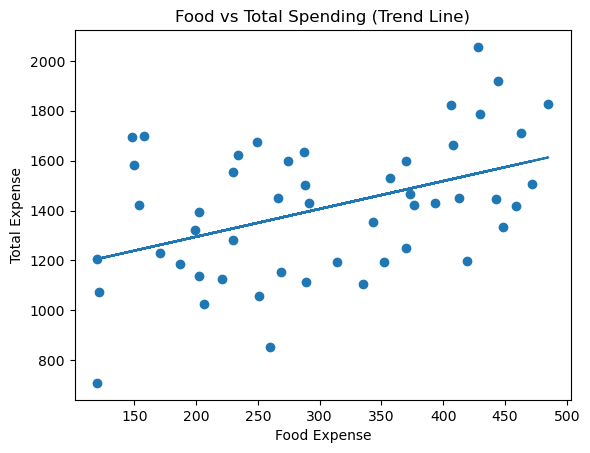


Class Distribution:
 High_Spending
0    25
1    25
Name: count, dtype: int64

Accuracy: 0.9


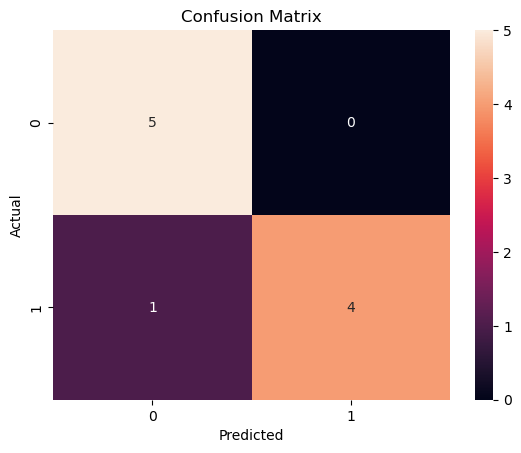

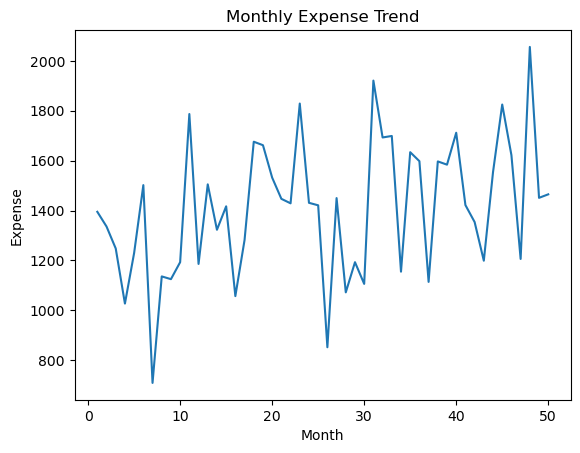

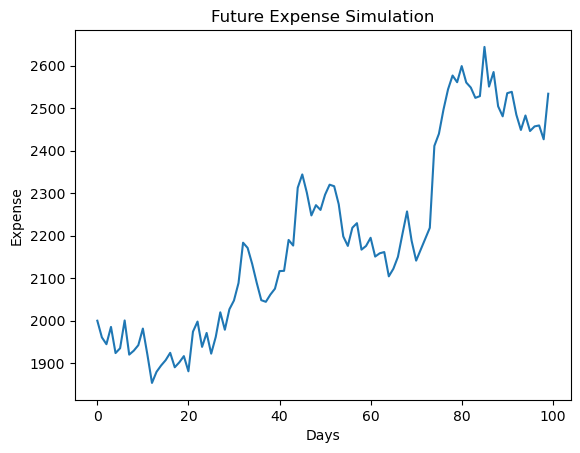

In [2]:
# IMPORT LIBRARIES #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import norm


# STEP 1: CREATE DATASET #

np.random.seed(42)

data = {
    "Food": np.random.randint(100, 500, 50),
    "Travel": np.random.randint(50, 300, 50),
    "Shopping": np.random.randint(100, 700, 50),
    "Bills": np.random.randint(200, 600, 50),
    "Others": np.random.randint(50, 200, 50)
}

df = pd.DataFrame(data)
df["Total"] = df.sum(axis=1)

df.to_csv("expenses.csv", index=False)

print("Dataset:\n", df.head())


# STEP 2: HANDLE MISSING VALUES #

df.fillna(df.mean(numeric_only=True), inplace=True)


# STEP 3: NUMPY OPERATIONS #

arr = df.values
print("\nMean:", np.mean(arr))
print("Sum:", np.sum(arr))
print("Shape:", arr.shape)


# STEP 4: SAMPLING #

sample = df.sample(frac=0.25, random_state=42)
print("\nSample Data:\n", sample)

# STEP 5: CORRELATION HEATMAP #

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Expense Correlation")
plt.show()


# STEP 6: Z-TEST #

sample_mean = np.mean(df["Total"])
std = np.std(df["Total"], ddof=1)
n = len(df)

z = (sample_mean - 2000) / (std / np.sqrt(n))
critical = norm.ppf(0.95)

print("\nZ-score:", round(z,2))

if z > critical:
    print("Reject Null Hypothesis (High Spending)")
else:
    print("Fail to Reject Null Hypothesis")


# STEP 7: ANALYSIS #

print("\nAverage Spending:\n", df.mean(numeric_only=True))

print("Highest Spending Index:", df["Total"].idxmax())
print("Lowest Spending Index:", df["Total"].idxmin())


# STEP 8: LINEAR REGRESSION #

X_lr = df[["Food"]]
y_lr = df["Total"]

lr_model = LinearRegression()
lr_model.fit(X_lr, y_lr)

y_pred_lr = lr_model.predict(X_lr)

plt.figure()
plt.scatter(X_lr, y_lr)
plt.plot(X_lr, y_pred_lr)
plt.title("Food vs Total Spending (Trend Line)")
plt.xlabel("Food Expense")
plt.ylabel("Total Expense")
plt.show()

# STEP 9: LOGISTIC REGRESSION #

# Balanced target
threshold = df["Total"].median()
df["High_Spending"] = (df["Total"] > threshold).astype(int)

print("\nClass Distribution:\n", df["High_Spending"].value_counts())

X = df[["Food","Travel","Shopping","Bills","Others"]]
y = df["High_Spending"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred),2))

# Confusion Matrix (no warning)
cm = confusion_matrix(y_test, y_pred, labels=[0,1])

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# STEP 10: TREND GRAPH #

df["Month"] = np.arange(1, 51)

plt.figure()
plt.plot(df["Month"], df["Total"])
plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.show()


# STEP 11: SIMULATION # 

def simulate_expense(start, days):
    values = [start]
    for i in range(1, days):
        change = np.random.normal(0, 50)
        values.append(values[-1] + change)
    return values

simulated = simulate_expense(2000, 100)

plt.figure()
plt.plot(simulated)
plt.title("Future Expense Simulation")
plt.xlabel("Days")
plt.ylabel("Expense")
plt.show()